## About the Dataset

This dataset contains satellite-detected wildfire hotspots, enriched with daily weather data, across seven fire-prone regions worldwide. It is designed for machine learning research focused on wildfire risk prediction, intensity classification, and seasonal pattern analysis.

### Coverage

- **Regions:** South Asia, Southeast Asia, Mediterranean, Sub-Saharan Africa, South America, North America, Australia  
- **Date Range:** January 2024 – December 2025  
- **Events:** 15,500 fire detection events across 35 countries  

### Features

- **latitude, longitude:** Geographic coordinates of the fire event  
- **acq_date:** Date of fire detection  
- **acq_time:** Time of fire detection (HHMM format)  
- **year, month:** Year and month of detection  
- **season:** Season of the year (e.g., summer, winter)  
- **daynight:** Indicates if the fire was detected during the day or night  
- **region:** Geographic region of the fire event  
- **country:** Country where the fire occurred  
- **fire_type:** Type of fire event (Wildfire, Agriculture, Peatland, Savanna)  
- **satellite:** Satellite used for detection (NOAA-20, Suomi-NPP)  
- **instrument:** Sensor/instrument used (VIIRS, MODIS)  
- **brightness_k:** Brightness temperature in Kelvin (related to fire activity)  
- **confidence:** Detection confidence level (high, nominal, low)  
- **temp_max_c:** Maximum air temperature on detection day (°C)  
- **wind_max_kmh:** Maximum wind speed (km/h), important for fire spread  
- **precip_mm:** Precipitation (proxy for fire suppression)  
- **humidity_pct:** Relative humidity (%)  

### Target Variable

- **fire_intensity:** Intensity level of the wildfire (categorical, 4 classes):  
    - 0 = Low  
    - 1 = Moderate  
    - 2 = High  
    - 3 = Extreme

In [83]:
# Importing essential libraries for data analysis and visualization
import numpy as np  # Numerical operations
import pandas as pd  # Data manipulation
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Statistical data visualization

In [84]:
# Load the wildfire dataset for analysis
df = pd.read_csv("../data/raw/wildfire_multi_region_dataset.csv")  # Ensure the path is correct

#### Lets see the head and tail of the dataset to get a better understanding of the data.

In [85]:
# Display the first five rows to preview the data structure
df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Summer,D,Australia,Australia,...,TERRA,MODIS,347.72,29.38,Moderate,high,42.1,1.7,0.47,18.4
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,357.82,62.05,High,nominal,43.8,2.2,0.27,11.7
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,333.76,3.35,Low,high,35.4,4.4,0.35,5.0
3,-10.0978,149.8371,2024-01-02,206,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,323.94,46.35,Moderate,high,39.6,34.7,0.30,39.1
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,359.59,434.80,Extreme,high,46.7,16.7,6.49,53.1


In [86]:
# Display the last five rows to check for any anomalies at the end of the dataset
df.tail()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
15495,-29.5180,4.4481,2025-10-31,912,2025,10,Spring,D,Sub_Saharan_Africa,DRC,...,Suomi-NPP,VIIRS,348.45,77.70,High,low,29.8,0.6,2.55,12.7
15496,1.8911,38.6745,2025-10-31,101,2025,10,Autumn,N,Sub_Saharan_Africa,South Africa,...,Suomi-NPP,VIIRS,339.74,78.96,High,high,35.7,0.5,1.13,7.9
15497,-3.7720,-16.7081,2025-10-31,136,2025,10,Spring,N,Sub_Saharan_Africa,Mozambique,...,TERRA,MODIS,350.10,221.90,Extreme,high,34.2,4.9,1.15,20.1
15498,6.5688,-12.5954,2025-10-31,313,2025,10,Autumn,N,Sub_Saharan_Africa,Angola,...,Suomi-NPP,VIIRS,356.97,68.71,High,low,46.9,17.4,1.72,28.2
15499,-27.7634,44.2033,2025-10-31,1224,2025,10,Spring,D,Sub_Saharan_Africa,Angola,...,Suomi-NPP,VIIRS,306.19,123.82,High,high,36.3,8.7,3.28,11.4


### Inspection of the dataset

In [87]:
# List all column names to understand available features
df.columns

Index(['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month',
       'season', 'daynight', 'region', 'country', 'fire_type', 'satellite',
       'instrument', 'brightness_k', 'frp_mw', 'fire_intensity', 'confidence',
       'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct'],
      dtype='str')

In [88]:
# Check the shape of the dataset (rows, columns)
df.shape

(15500, 21)

In [89]:
# Get a concise summary of the DataFrame, including non-null counts and dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        15500 non-null  float64
 1   longitude       15500 non-null  float64
 2   acq_date        15500 non-null  str    
 3   acq_time        15500 non-null  int64  
 4   year            15500 non-null  int64  
 5   month           15500 non-null  int64  
 6   season          15500 non-null  str    
 7   daynight        15500 non-null  str    
 8   region          15500 non-null  str    
 9   country         15500 non-null  str    
 10  fire_type       15500 non-null  str    
 11  satellite       15500 non-null  str    
 12  instrument      15500 non-null  str    
 13  brightness_k    15500 non-null  float64
 14  frp_mw          15500 non-null  float64
 15  fire_intensity  15500 non-null  str    
 16  confidence      15500 non-null  str    
 17  temp_max_c      15500 non-null  float64
 1

In [90]:
# Count the number of columns by data type
df.dtypes.value_counts()

str        10
float64     8
int64       3
Name: count, dtype: int64

In [91]:
# Generate descriptive statistics for numerical features
df.describe()

,latitude,longitude,acq_time,year,month,brightness_k,frp_mw,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000
mean,10.251489,29.204768,1177.268645,2024.503032,7.244774,336.501241,80.181982,35.099335,17.783774,2.595579,38.136716
std,24.367098,78.693275,689.540417,0.500007,2.768195,19.209340,150.411669,5.850954,17.617369,3.154769,18.890952
min,-42.990800,-167.990600,0.000000,2024.000000,1.000000,290.000000,0.370000,12.800000,0.000000,0.000000,5.000000
25%,-7.561575,-41.641000,600.000000,2024.000000,5.000000,324.570000,15.010000,31.000000,5.100000,0.610000,24.300000
50%,10.477350,34.807950,1200.000000,2025.000000,8.000000,335.170000,35.445000,35.200000,12.500000,1.520000,36.300000
75%,30.104450,95.064200,1756.000000,2025.000000,9.000000,346.670000,83.720000,39.200000,24.700000,3.330000,50.800000
max,69.982600,153.987500,2359.000000,2025.000000,12.000000,574.860000,3000.000000,55.500000,188.800000,34.440000,95.000000


### Target Variable = fire_intensity

In [92]:
# Check the distribution of the target variable 'fire_intensity'
df['fire_intensity'].value_counts()

fire_intensity
Moderate    6861
High        4785
Low         2493
Extreme     1361
Name: count, dtype: int64

### Lets see the distribution of the target variable.

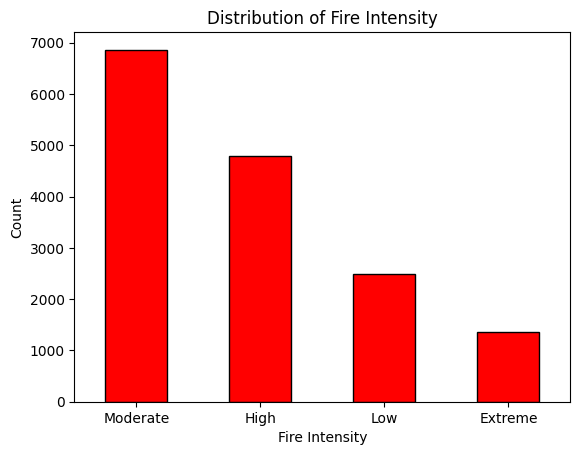

In [93]:
# Visualize the distribution of fire intensity classes
df['fire_intensity'].value_counts().plot(kind='bar', color='red', edgecolor='black')
plt.title('Distribution of Fire Intensity')
plt.xlabel('Fire Intensity')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Missing Values Analysis

In [94]:
# Check for missing values in each column, sorted by most missing
df.isnull().sum().sort_values(ascending=False)

latitude          0
longitude         0
acq_date          0
acq_time          0
year              0
month             0
season            0
daynight          0
region            0
country           0
fire_type         0
satellite         0
instrument        0
brightness_k      0
frp_mw            0
fire_intensity    0
confidence        0
temp_max_c        0
wind_max_kmh      0
precip_mm         0
humidity_pct      0
dtype: int64

### Feature Type Separation

In [95]:
# Separate features into numeric and categorical for further analysis
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns  # Quantitative features
categorical_features = df.select_dtypes(include=['object', 'str']).columns  # Qualitative features

In [96]:
# Display lists of numeric and categorical features
numeric_features, categorical_features

(Index(['latitude', 'longitude', 'acq_time', 'year', 'month', 'brightness_k',
        'frp_mw', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct'],
       dtype='str'),
 Index(['acq_date', 'season', 'daynight', 'region', 'country', 'fire_type',
        'satellite', 'instrument', 'fire_intensity', 'confidence'],
       dtype='str'))

In [97]:
# List all numeric feature names
numeric_features.tolist()

['latitude',
 'longitude',
 'acq_time',
 'year',
 'month',
 'brightness_k',
 'frp_mw',
 'temp_max_c',
 'wind_max_kmh',
 'precip_mm',
 'humidity_pct']

In [98]:
# List all categorical feature names
categorical_features.tolist()

['acq_date',
 'season',
 'daynight',
 'region',
 'country',
 'fire_type',
 'satellite',
 'instrument',
 'fire_intensity',
 'confidence']

### Check imbalance impact

In [99]:
# Check the proportion of each fire intensity class to assess class imbalance
df['fire_intensity'].value_counts(normalize=True)

fire_intensity
Moderate    0.442645
High        0.308710
Low         0.160839
Extreme     0.087806
Name: proportion, dtype: float64

### Lets see correlation between numeric features

In [ ]:
# Compute the correlation matrix for numeric features to explore relationships
df[numeric_features].corr()

,latitude,longitude,acq_time,year,month,brightness_k,frp_mw,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
latitude,1.000000,-0.148462,-0.012513,0.004707,-0.063120,-0.011671,-0.021155,0.063895,-0.001931,0.000428,-0.042387
longitude,-0.148462,1.000000,0.002547,0.016116,-0.280015,-0.091273,-0.140272,-0.175054,0.013338,0.171234,0.473339
acq_time,-0.012513,0.002547,1.000000,0.008753,0.003198,-0.006892,-0.007460,0.000732,-0.001830,0.006499,0.002323
year,0.004707,0.016116,0.008753,1.000000,0.000909,0.003754,0.005019,0.013098,-0.010393,-0.011800,-0.003520
month,-0.063120,-0.280015,0.003198,0.000909,1.000000,0.027667,0.040453,0.490223,-0.007972,-0.077590,-0.222361
brightness_k,-0.011671,-0.091273,-0.006892,0.003754,0.027667,1.000000,0.629772,0.056593,-0.006230,-0.023245,-0.068368
frp_mw,-0.021155,-0.140272,-0.007460,0.005019,0.040453,0.629772,1.000000,0.078276,-0.006890,-0.043845,-0.111909
temp_max_c,0.063895,-0.175054,0.000732,0.013098,0.490223,0.056593,0.078276,1.000000,-0.012711,-0.098506,-0.263137
wind_max_kmh,-0.001931,0.013338,-0.001830,-0.010393,-0.007972,-0.006230,-0.006890,-0.012711,1.000000,-0.004705,0.016538
precip_mm,0.000428,0.171234,0.006499,-0.011800,-0.077590,-0.023245,-0.043845,-0.098506,-0.004705,1.000000,0.328516


### At this stage



## Summary: What Has Been Done So Far

- **Loaded the wildfire dataset** and explored its structure (head, tail, columns, shape, info, dtypes, descriptive statistics).
- **Inspected the target variable** (`fire_intensity`) and visualized its distribution.
- **Checked for missing values** across all features.
- **Separated features** into numeric and categorical types for further analysis.
- **Listed all numeric and categorical features** for reference.
- **Assessed class imbalance** in the target variable.
- **Explored correlations** among numeric features.
